<a href="https://colab.research.google.com/github/xyz111131/AI-Tools-for-Statistical-Research/blob/main/gradients.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [ ]:
class DeepMLP(nn.Module):
    def __init__(self, depth=12, width=128, activation="relu"):
        super().__init__()
        act_cls = {"relu": nn.ReLU,
                   "tanh": nn.Tanh,
                   "sigmoid": nn.Sigmoid}[activation]
        self.linears = nn.ModuleList(
            [nn.Linear(width, width, bias=False) for _ in range(depth)]
        )
        self.act = act_cls()
        self.head = nn.Linear(width, 10, bias=False)

    def forward(self, x):
        # We retain_grad() on each post-activation so we can read d L / d a_l.
        self._acts = []
        h = x
        for lin in self.linears:
            h = self.act(lin(h))
            h.retain_grad()
            self._acts.append(h)
        return self.head(h)


In [ ]:
def init_healthy(model):
    for lin in list(model.linears) + [model.head]:
        nn.init.kaiming_normal_(lin.weight, nonlinearity="relu")


def init_exploding(model, std=0.8):
    for lin in list(model.linears) + [model.head]:
        nn.init.normal_(lin.weight, mean=0.0, std=std)


def init_vanishing(model, std=0.1):
    for lin in list(model.linears) + [model.head]:
        nn.init.normal_(lin.weight, mean=0.0, std=std)

In [ ]:
def measure(model, x, y, loss_fn):
    model.zero_grad()
    loss = loss_fn(model(x), y)
    loss.backward()

    # ||d L / d a_l||  -- the compounding quantity the slide visualizes
    act_grad_norms = [a.grad.norm().item() for a in model._acts]
    # ||d L / d W_l||  -- what you'd actually log during training
    weight_grad_norms = [lin.weight.grad.norm().item() for lin in model.linears]
    return act_grad_norms, weight_grad_norms


layer        Healthy      Exploding      Vanishing   [activation-gradient norms]
L1         1.901e-01      1.019e+09      5.440e-08 
L2         1.913e-01      1.601e+08      2.081e-07 
L3         1.834e-01      2.595e+07      7.743e-07 
L4         1.833e-01      4.060e+06      2.865e-06 
L5         1.831e-01      6.767e+05      1.152e-05 
L6         1.830e-01      1.105e+05      4.334e-05 
L7         1.790e-01      1.816e+04      1.644e-04 
L8         1.834e-01      2.858e+03      6.414e-04 
L9         1.833e-01      4.310e+02      2.375e-03 
L10        1.777e-01      6.345e+01      9.206e-03 
L11        1.784e-01      1.020e+01      3.443e-02 
L12        1.753e-01      1.553e+00      1.312e-01 

Saved figure to gradient_norms.png


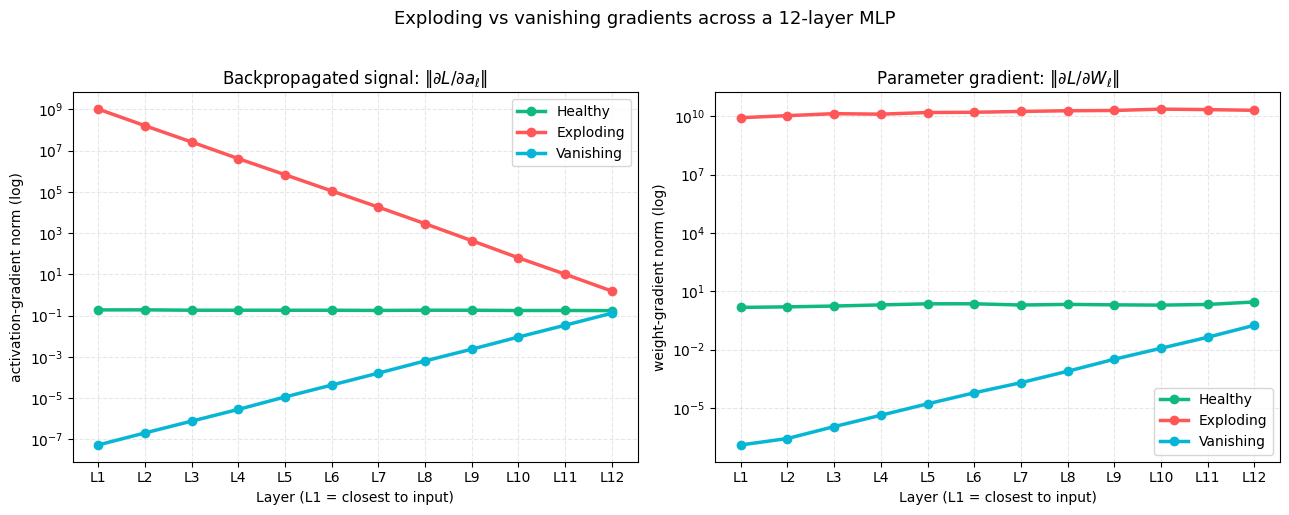

In [ ]:
torch.manual_seed(0)

B, D, depth = 64, 128, 12
x = torch.randn(B, D)
y = torch.randint(0, 10, (B,))
loss_fn = nn.CrossEntropyLoss()

regimes = [
    ("Healthy",   DeepMLP(depth, D, "relu"),   init_healthy,   "#10B981"),
    ("Exploding", DeepMLP(depth, D, "relu"),    init_exploding, "#FF5757"),
    ("Vanishing", DeepMLP(depth, D, "sigmoid"), init_vanishing, "#06B6D4"),
]

results = {}
for name, model, init_fn, _ in regimes:
    init_fn(model)
    act_norms, w_norms = measure(model, x, y, loss_fn)
    results[name] = (act_norms, w_norms)

# Sanity table
print(f"{'layer':<5} " + " ".join(f"{n:>14}" for n, *_ in regimes)
      + "   [activation-gradient norms]")
for i in range(depth):
    row = f"L{i+1:<4} "
    for n, *_ in regimes:
        row += f"{results[n][0][i]:>14.3e} "
    print(row)

# Two-panel figure
xs = [f"L{i+1}" for i in range(depth)]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for name, _, _, color in regimes:
    ax1.plot(xs, results[name][0], marker="o", linewidth=2.5,
              color=color, label=name)
    ax2.plot(xs, results[name][1], marker="o", linewidth=2.5,
              color=color, label=name)

for ax, title, ylabel in [
    (ax1, "Backpropagated signal: "
          r"$\Vert \partial L / \partial a_\ell \Vert$",
      "activation-gradient norm (log)"),
    (ax2, "Parameter gradient: "
          r"$\Vert \partial L / \partial W_\ell \Vert$",
      "weight-gradient norm (log)"),
]:
    ax.set_yscale("log")
    ax.set_xlabel("Layer (L1 = closest to input)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, which="both", linestyle="--", alpha=0.3)
    ax.legend()

fig.suptitle("Exploding vs vanishing gradients across a 12-layer MLP",
              fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig("gradient_norms.png", dpi=150, bbox_inches="tight")
print("\nSaved figure to gradient_norms.png")